# Part 1: Modulo Behavior with Linear Shifts

# $c = b + kp \mod p \rightarrow c = b$ 

Goal: Demonstrate that for any integer $k$, adding $kp$ doesn't affect $b \mod p$

In [13]:
# Homomorphic Encryption Exploration - Gentry-style Toy Model
import numpy as np
import matplotlib.pyplot as plt

# PART 1: Explore c = b + k*p mod p
def explore_modulo_equivalence(b=0, p=11):
    k_range=(0, p)
    ks = list(range(k_range[0], k_range[1]))
    values = [(b + k * p) % p for k in ks]
    
    print(f"Exploring c = b + kp mod p with b={b}, p={p}")
    for k, val in zip(ks, values):
        print(f"k = {k:2d} --> (b + k*p) mod p = {val}")
    
    plt.figure(figsize=(8, 4))
    plt.plot(ks, values, 'o-', label=f'(b + k*p) mod p')
    plt.axhline(b, color='red', linestyle='--', label='Original b')
    plt.title('Modulo Equivalence: (b + k*p) mod p = b')
    plt.xlabel('k')
    plt.ylabel('Result mod p')
    plt.grid(True)
    plt.legend()
    plt.show()


Exploring c = b + kp mod p with b=1, p=11
k =  0 --> (b + k*p) mod p = 1
k =  1 --> (b + k*p) mod p = 1
k =  2 --> (b + k*p) mod p = 1
k =  3 --> (b + k*p) mod p = 1
k =  4 --> (b + k*p) mod p = 1
k =  5 --> (b + k*p) mod p = 1
k =  6 --> (b + k*p) mod p = 1
k =  7 --> (b + k*p) mod p = 1
k =  8 --> (b + k*p) mod p = 1
k =  9 --> (b + k*p) mod p = 1
k = 10 --> (b + k*p) mod p = 1


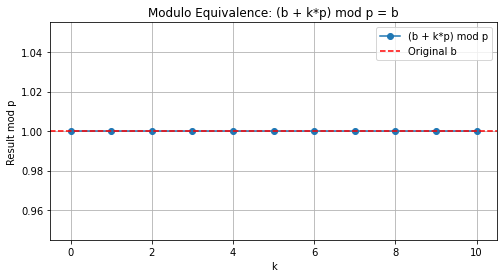

In [19]:
# run it
explore_modulo_equivalence(b=1, p=11)

# $c = b + 2r + kp \mod p \rightarrow c = b + 2r$

Decryption:
- $(c \mod p) \mod 2$

We'll visualize:
- how decryption works when $|b+2r| < p$
- what happens when this condition is violated

In [28]:
# PART 2: Explore correctness of FHE decryption (c mod p) mod 2 = b
def explore_decryption_with_noise(b=1, p=23, k=0):
    r_range=(0, 2*p)
    rs = list(range(r_range[0], r_range[1]))
    cs = [b + 2*r + k*p for r in rs]
    decrypted = [((c % p) % 2) for c in cs]
    noise_terms = [b + 2*r for r in rs]
    correctness = [int(abs(n) < p) for n in noise_terms]  # 1 if decryption should work

    print(f"Exploring decryption with b={b}, p={p}, k={k}")
    print(f"{'r':>3} {'c':>6} {'c mod p':>8} {'decrypted':>10} {'correct':>9}")
    for r, c, d, ok in zip(rs, cs, decrypted, correctness):
        print(f"{r:3d} {c:6d} {c%p:8d} {d:10d} {str(bool(ok)):>9}")

    plt.figure(figsize=(10, 5))
    plt.plot(rs, decrypted, 'o-', label='Decrypted bit')
    plt.plot(rs, [b]*len(rs), '--', label='Expected b', alpha=0.5)
    plt.fill_between(rs, 0, 1, where=[ok == 1 for ok in correctness],
                     color='green', alpha=0.1, label='Decryption works')
    plt.fill_between(rs, 0, 1, where=[ok == 0 for ok in correctness],
                     color='red', alpha=0.1, label='Decryption fails')

    plt.title('Correctness of FHE Decryption vs. Noise Level (b + 2r)')
    plt.xlabel('r')
    plt.ylabel('Decrypted bit')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Exploring decryption with b=1, p=11, k=0
  r      c  c mod p  decrypted   correct
  0      1        1          1      True
  1      3        3          1      True
  2      5        5          1      True
  3      7        7          1      True
  4      9        9          1      True
  5     11        0          0     False
  6     13        2          0     False
  7     15        4          0     False
  8     17        6          0     False
  9     19        8          0     False
 10     21       10          0     False
 11     23        1          1     False
 12     25        3          1     False
 13     27        5          1     False
 14     29        7          1     False
 15     31        9          1     False
 16     33        0          0     False
 17     35        2          0     False
 18     37        4          0     False
 19     39        6          0     False
 20     41        8          0     False
 21     43       10          0     False


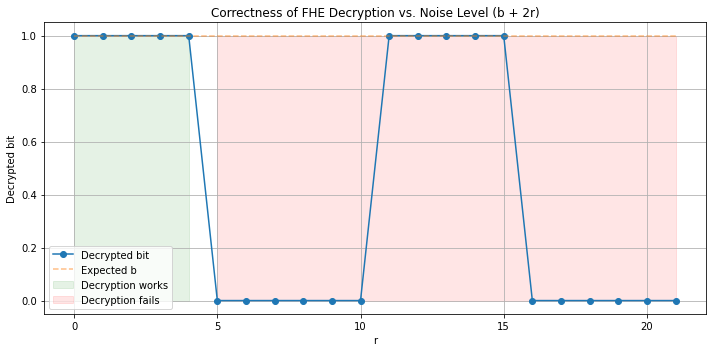

In [29]:
# run it
explore_decryption_with_noise(b=1, p=11, k=0)

# FHE Scheme

Encryption:
- $c = b + 2r + kp$

Decryption:
- $b = (c \mod p) \mod 2$

In [35]:
def encrypt(b, p, r=None, k=None):
    """Encrypt a bit b ∈ {0,1} with secret p."""
    if r is None:
        r = np.random.randint(0, 5)
    if k is None:
        k = np.random.randint(0, 5)
    return b + 2*r + k*p, r, k

def decrypt(c, p):
    """Decrypt ciphertext."""
    return (c % p) % 2

def demo_homomorphic_operations(p=97):
    # Choose two bits
    b1, b2 = 1, 0

    # Encrypt both
    c1, r1, k1 = encrypt(b1, p)
    c2, r2, k2 = encrypt(b2, p)

    print(f"b1 = {b1}, encrypted as c1 = {c1} (r={r1}, k={k1})")
    print(f"b2 = {b2}, encrypted as c2 = {c2} (r={r2}, k={k2})")

    # Homomorphic addition
    c_add = c1 + c2
    b_add = decrypt(c_add, p)
    print(f"\nHomomorphic Addition:")
    print(f"c_add = c1 + c2 = {c_add}")
    print(f"Decrypted: {b_add} (should be {(b1 + b2) % 2})")

    # Homomorphic multiplication (only works for small r, small k)
    c_mult = c1 * c2
    b_mult = decrypt(c_mult, p)
    print(f"\nHomomorphic Multiplication:")
    print(f"c_mult = c1 * c2 = {c_mult}")
    print(f"Decrypted: {b_mult} (should be {(b1 * b2) % 2})")


In [41]:
# Run the demonstration
demo_homomorphic_operations(p=97)

b1 = 1, encrypted as c1 = 397 (r=4, k=4)
b2 = 0, encrypted as c2 = 200 (r=3, k=2)

Homomorphic Addition:
c_add = c1 + c2 = 597
Decrypted: 1 (should be 1)

Homomorphic Multiplication:
c_mult = c1 * c2 = 79400
Decrypted: 0 (should be 0)


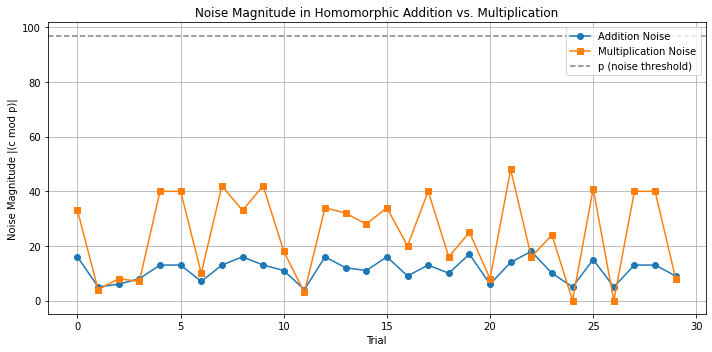

In [45]:
def compute_noise(c, p):
    """Compute effective noise = (c mod p), centered around 0."""
    mod_p = c % p
    if mod_p > p // 2:
        return mod_p - p  # center around 0
    else:
        return mod_p

def visualize_noise_growth(p=97, trials=30):
    noise_add = []
    noise_mult = []

    for _ in range(trials):
        # Encrypt two random bits
        b1, b2 = np.random.randint(0, 2), np.random.randint(0, 2)
        c1, r1, k1 = encrypt(b1, p)
        c2, r2, k2 = encrypt(b2, p)

        # Homomorphic addition
        c_add = c1 + c2
        n_add = compute_noise(c_add, p)
        noise_add.append(abs(n_add))

        # Homomorphic multiplication
        c_mult = c1 * c2
        n_mult = compute_noise(c_mult, p)
        noise_mult.append(abs(n_mult))

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(noise_add, 'o-', label='Addition Noise')
    plt.plot(noise_mult, 's-', label='Multiplication Noise')
    plt.axhline(p, color='gray', linestyle='--', label='p (noise threshold)')
    plt.title("Noise Magnitude in Homomorphic Addition vs. Multiplication")
    plt.xlabel("Trial")
    plt.ylabel("Noise Magnitude |(c mod p)|")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run the visualisation
visualize_noise_growth(p=97, trials=30)

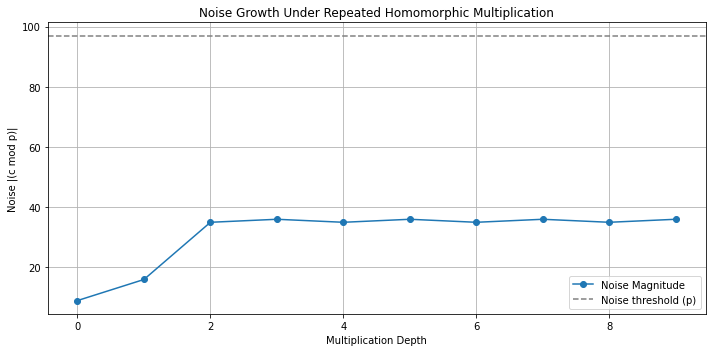

Depth 0: Decrypted = 1 ✅ | Noise = 9
Depth 1: Decrypted = 1 ✅ | Noise = 16
Depth 2: Decrypted = 0 ❌ | Noise = 35
Depth 3: Decrypted = 1 ✅ | Noise = 36
Depth 4: Decrypted = 1 ✅ | Noise = 35
Depth 5: Decrypted = 1 ✅ | Noise = 36
Depth 6: Decrypted = 1 ✅ | Noise = 35
Depth 7: Decrypted = 1 ✅ | Noise = 36
Depth 8: Decrypted = 1 ✅ | Noise = 35
Depth 9: Decrypted = 1 ✅ | Noise = 36


In [58]:
def repeated_multiplications(p=97, depth=10):
    """Simulate repeated homomorphic multiplication."""
    # Start with encrypted b = 1
    b = 1
    c, r, k = encrypt(b, p)
    noise = compute_noise(c, p)
    
    cs = [c]
    noises = [abs(noise)]
    decrypts = [decrypt(c, p)]

    for i in range(1, depth):
        c = c * cs[-1]  # c^2, c^3, ...
        n = compute_noise(c, p)
        d = decrypt(c, p)


        cs.append(c)
        noises.append(abs(n))
        decrypts.append(d)

    # Plot noise growth
    plt.figure(figsize=(10, 5))
    plt.plot(noises, marker='o', label='Noise Magnitude')
    plt.axhline(p, color='gray', linestyle='--', label='Noise threshold (p)')
    plt.title("Noise Growth Under Repeated Homomorphic Multiplication")
    plt.xlabel("Multiplication Depth")
    plt.ylabel("Noise |(c mod p)|")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Show decryption correctness
    for i, d in enumerate(decrypts):
        correct = "✅" if d == 1 else "❌"
        print(f"Depth {i}: Decrypted = {d} {correct} | Noise = {noises[i]}")

# Run the demo
repeated_multiplications(p=97, depth=10)